In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from typing import List
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
import matplotlib.pyplot as plt
sys.path.append('../..')

In [13]:
from src import train, utils
from src import calculus as calc
import src.data.aquarium_domain as aq
import src.models.mlp_model as mm

In [14]:
NU = 0.001
U_MAX = 0.3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
domain_ctx = aq.AquariumContext(
    dim=2,
    l_bounds=(0, 0),
    u_bounds=(2.2, 0.42),
    N_int=10_000,
    N_sides=[(1000, 1000), (1000, 1000)],
    device=device,
    ball_centre=torch.tensor([0.2, 0.2], device=device),
    ball_r=0.05
)

domain = aq.AquariumDomain(domain_ctx)
domain.generate_points()

In [16]:
def loss_stream(model: torch.nn.Module, domain: aq.AquariumDomain) -> List[torch.Tensor]:
    # ztrata na vnitrku
    _, _, u, v, u_x, u_y, v_x, v_y, u_xx, u_yy, v_xx, v_yy, p_x, p_y = calc.compute_derivatives_ns(model, domain.interior)
    inner_loss_1 = torch.mean((-NU * (u_xx + u_yy) + u * u_x + v * u_y + p_x)**2)
    inner_loss_2 = torch.mean((-NU * (v_xx + v_yy) + u * v_x + v * v_y + p_y)**2)
    inner_loss = inner_loss_1 + inner_loss_2

    # ztrata na leve hranici: x=0
    _, v_left, u_left = calc.compute_derivatives_2d(model, domain.sides[0][0], 0)

    inflow = 4 * U_MAX * domain.sides[0][0][:, 1:2] * (domain.ctx.u_bounds[1] - domain.sides[0][0][:, 1:2]) / (domain.ctx.u_bounds[1]**2)
    left_loss = torch.mean((u_left - inflow)**2 + v_left**2)

    # ztrata na prave hranici: x=2.2
    in_right = domain.sides[0][1].requires_grad_(True)
    out_right = model(in_right)
    psi_right, p_right = out_right[:, 0], out_right[:, 1]
    psi_right_grad = grad(psi_right, in_right, torch.ones_like(psi_right), create_graph=True)[0]
    v_right, u_right = -psi_right_grad[:, 0:1], psi_right_grad[:, 1:2]
    v_right_x = grad(v_right, in_right, torch.ones_like(v_right), create_graph=True)[0][:, 0:1]
    u_right_x = grad(u_right, in_right, torch.ones_like(u_right), create_graph=True)[0][:, 0:1]

    right_loss = torch.mean((NU * u_right_x - p_right)**2 + v_right_x**2)

    # ztrata na horni hranici: y=0.42
    sides = torch.cat([domain.sides[1][1], domain.sides[1][0], domain.ball_boundary], dim=0).requires_grad_(True)
    psi_sides = model(sides)[:, :-1]
    psi_sides_grad = grad(psi_sides, sides, torch.ones_like(psi_sides), create_graph=True)[0]
    side_loss = torch.mean(psi_sides_grad[:, 0:1]**2 + psi_sides_grad[:, 1:2]**2)
    
    return [inner_loss, left_loss, right_loss, side_loss]

In [17]:
def int_residuum(output: torch.Tensor, input: torch.Tensor) -> torch.Tensor:
    psi, p = output[:, :-1], output[:, -1:]
    u = grad(psi, input, torch.ones_like(psi), create_graph=True)[0]
    residuum = calc.material_derivative(input, u, device=device, time_dependant=True) +\
               calc.nabla(input, p, retain=True) - NU * calc.laplacian(input, u, device=device, time_dependant=False)
    return residuum


def continuity_residuum(output: torch.Tensor, input: torch.Tensor) -> torch.Tensor:
    u, v = output[:, 0:1], output[:, 1:2]
    u_x = grad(u, input, torch.ones_like(u), create_graph=True)[0][:, 0:1]
    v_y = grad(v, input, torch.ones_like(v), create_graph=True)[0][:, 1:2]
    return u_x + v_y


def loss_no_stream(model: torch.nn.Module, domain: aq.AquariumDomain) -> List[torch.Tensor]:
    # ztrata na vnitrku
    pde_intput = domain.interior.requires_grad_(True)
    pde_output = model(pde_intput)
    pde_res = int_residuum(pde_output, pde_intput)
    inner_loss = torch.mean(pde_res[:, 0:1]**2 + pde_res[:, 1:2]**2)
    
    # ztrata na leve hranici
    input_left = domain.sides[0][0].requires_grad_(True)
    output_left = model(input_left)
    psi_left = output_left[:, :-1]
    u_left = grad(psi_left, input_left, torch.ones_like(psi_left), create_graph=True)[0]
    inflow = 4 * U_MAX * input_left[:, 1:2] * (domain.ctx.u_bounds[1] - input_left[:, 1:2]) / (domain.ctx.u_bounds[1]**2)
    left_loss = torch.mean((u_left[:, 0:1] - inflow)**2 + u_left[:, 1:2]**2)
    
    # ztrata na prave hranici
    input_right = domain.sides[0][1].requires_grad_(True)
    output_right = model(input_right)
    psi_right, p_right = output_right[:, :-1], output_right[:, -1:]
    u_right = grad(psi_right, input_right, torch.ones_like(psi_right), create_graph=True)[0]
    # print(u_right, p_right)
    u_right_x = grad(u_right[:, 0:1], input_right, torch.ones_like(u_right[:, 0:1]), create_graph=True)[0][:, 0:1]
    v_right_x = grad(u_right[:, 1:2], input_right, torch.ones_like(u_right[:, 1:2]), create_graph=True)[0][:, 0:1]
    right_loss = torch.mean((NU * u_right_x - p_right)**2 + v_right_x**2)
    # print(u_right_x, v_right_x)

    # ztrata na zbylych hranicich
    sides = torch.cat([domain.sides[1][1], domain.sides[1][0], domain.ball_boundary], dim=0).requires_grad_(True)
    psi_sides = model(sides)[:, :-1]
    u_sides = grad(psi_sides, sides, torch.ones_like(psi_sides), create_graph=True)[0]
    side_loss = torch.mean(u_sides[:, 0:1]**2 + u_sides[:, 1:2]**2)

    return [inner_loss, 10 * left_loss, right_loss, side_loss]

In [18]:
model_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=2,
    layer=[32, 32, 32, 32],
    u_bounds=domain_ctx.u_bounds,
    l_bounds=domain_ctx.l_bounds,
)

model_stream = mm.MLPModel(model_ctx).to(device=device)
optimizer_stream = torch.optim.Adam(model_stream.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer_stream, factor=0.5, patience=200)

In [19]:
context = train.TrainingContext(
    model=model_stream,
    domain=domain,
    optimizer=optimizer_stream,
    loss_fn=loss_stream,
    epochs=30_000,
    monitor_lr=True
)

total_loss_values, component_loss_values = train.simple_train(context)
context.optimizer = torch.optim.Adam(model_stream.parameters(), lr=0.0001)
total_loss_values_1, component_loss_values_1 = train.train_switch_to_lbfgs(context, lbfgs_lr=0.1)

total_loss_values += total_loss_values_1

for i in len(component_loss_values):
    component_loss_values[i] += component_loss_values_1[i]

Loss at epoch 1 is: 0.1696045696735382. Current learing rate: 0.001 
Loss at epoch 100 is: 0.00428045354783535. Current learing rate: 0.001 
Loss at epoch 200 is: 0.003898133523762226. Current learing rate: 0.001 
Loss at epoch 300 is: 0.003863210789859295. Current learing rate: 0.001 
Loss at epoch 400 is: 0.003835173323750496. Current learing rate: 0.001 
Loss at epoch 500 is: 0.003750450676307082. Current learing rate: 0.001 
Loss at epoch 600 is: 0.003695619758218527. Current learing rate: 0.001 
Loss at epoch 700 is: 0.003606544341892004. Current learing rate: 0.001 
Loss at epoch 800 is: 0.0035509306471794844. Current learing rate: 0.001 
Loss at epoch 900 is: 0.003484725020825863. Current learing rate: 0.001 
Loss at epoch 1000 is: 0.0034502272028476. Current learing rate: 0.001 
Loss at epoch 1100 is: 0.003977152518928051. Current learing rate: 0.001 
Loss at epoch 1200 is: 0.003392486134544015. Current learing rate: 0.001 
Loss at epoch 1300 is: 0.0032846706453710794. Current 

TypeError: 'int' object is not iterable

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/nav_stokes/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


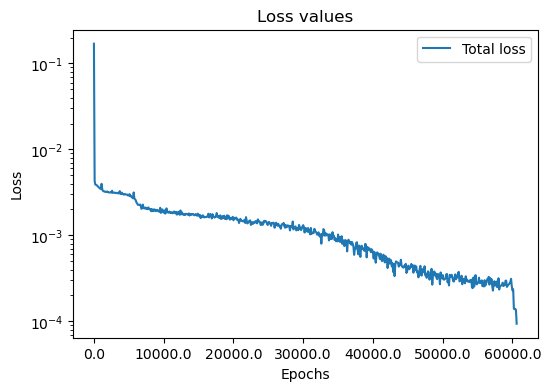

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/nav_stokes/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


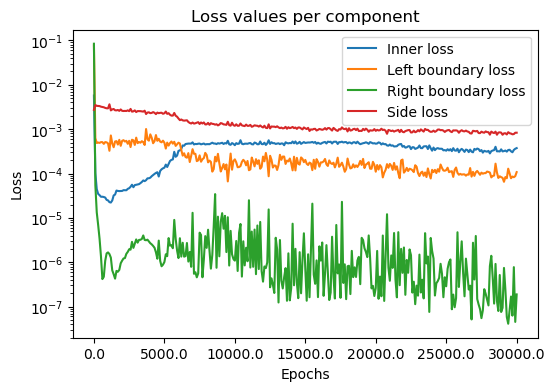

In [20]:
# vykresleni vyvoje ztraty
plot_context = utils.PlotContext(
    u_bounds=domain_ctx.u_bounds,
    l_bounds=domain_ctx.l_bounds,
    figsize=(25,3.85),
    patches=None,
    device=device,
    vmin=0.0,
    vmax=0.4,
    N=100,
    titles=['Velocity norm'],
    function_names=['u'],
    x_label='Epochs',
    y_label='Loss'
)

plot_context.titles = ["Loss values"]
utils.plot_loss_values({'Total loss': total_loss_values}, plot_context)
plot_context.titles = ["Loss values per component"]
utils.plot_loss_values({'Inner loss': component_loss_values[0],
                        'Left boundary loss': component_loss_values[1],
                        'Right boundary loss': component_loss_values[2],
                        'Side loss': component_loss_values[3]}, plot_context)

/home/berva/miniconda3/envs/torch/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/libtorch_1745854776362/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


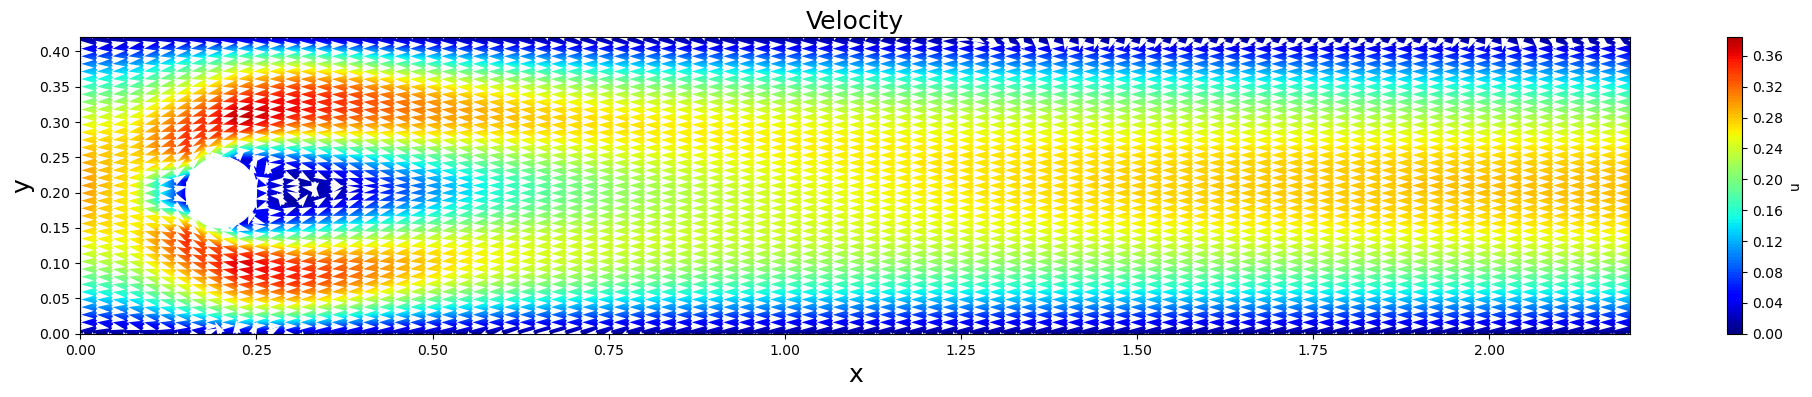

In [21]:
# vykresleni rychlosti kapaliny
plot_context.patches = [plt.Circle((0.2, 0.2), 0.05, color="white", zorder=10)]
plot_context.titles = ['Velocity']
plot_context.function_names = ['u']
plot_context.x_label = 'x'
plot_context.y_label = 'y'
plot_context.fontsize = 18

def u(x: torch.Tensor): 
    x.requires_grad_(True)
    psi = model_stream(x)[:, :-1]
    psi_grad = grad(psi, x, torch.ones_like(psi), create_graph=False)[0]
    
    return torch.cat([psi_grad[:, 1:2], -psi_grad[:, 0:1]], dim=1)

utils.plot_vector_field_2d([u], plot_context, N=30, n_heigth=40, n_width=100)

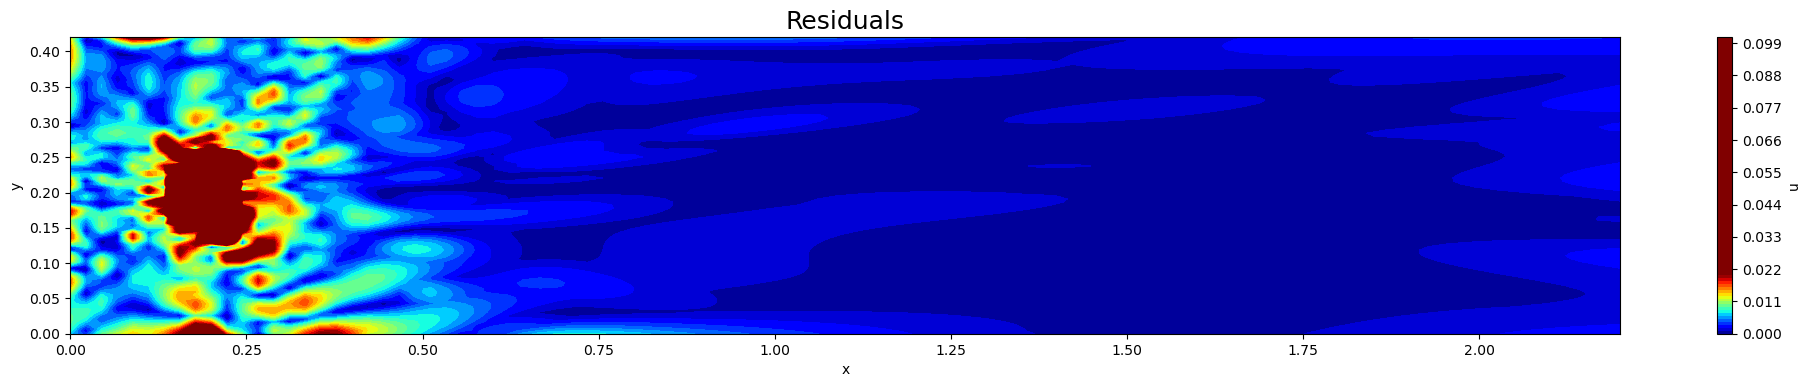

In [22]:
def residuum(x: torch.Tensor):
    x.requires_grad_(True)
    _, _, u, v, u_x, u_y, v_x, v_y, u_xx, u_yy, v_xx, v_yy, p_x, p_y = calc.compute_derivatives_ns(model_stream, x)
    res_1 = torch.clamp(torch.abs(-NU * (u_xx + u_yy) + u * u_x + v * u_y + p_x), 0, 0.1)
    res_2 = torch.clamp(torch.abs(-NU * (v_xx + v_yy) + u * v_x + v * v_y + p_y), 0, 0.1)
    return 0.5 * (res_1 + res_2)

def second_equation_residuum(x: torch.Tensor):
    x.requires_grad_(True)
    _, _, u, v, u_x, u_y, v_x, v_y, u_xx, u_yy, v_xx, v_yy, p_x, p_y = calc.compute_derivatives_ns(model_stream, x)
    return 


plot_context.vmin = 0
plot_context.vmax = 0.02
plot_context.patches = []

plot_context.titles = ['Residuals']
utils.plot_function_on_2d_cube([residuum], plot_context)

In [33]:
N_sample   = 7_000
alpha      = 3.0        # controls left-bias strength
ball_cx, ball_cy, ball_r = 0.21, 0.21, 0.05
N_annular  = 3_000      # extra points tightly around the ball
ann_r_max  = 0.2

x_lo, x_hi = domain_ctx.l_bounds[0], domain_ctx.u_bounds[0]
y_lo, y_hi = domain_ctx.l_bounds[1], domain_ctx.u_bounds[1]

# ── Main left-biased sample (u^alpha pushes mass toward 0) ────────────────────
def sample_left_biased(n: int) -> torch.Tensor:
    u_x  = torch.rand(n, device=device)
    x    = x_lo + (x_hi - x_lo) * (1.0 - u_x ** (1.0 / alpha))
    y    = y_lo + (y_hi - y_lo) * torch.rand(n, device=device)
    return torch.stack([x, y], dim=1)

# ── Annular sample around ball (uniform in thin ring) ─────────────────────────
def sample_annular(n: int) -> torch.Tensor:
    # uniform in annulus via inverse-CDF: r = sqrt(U*(r_max²-r_min²) + r_min²)
    r_min  = ball_r
    r_max  = ann_r_max
    u_r    = torch.rand(n, device=device)
    r      = torch.sqrt(u_r * (r_max**2 - r_min**2) + r_min**2)
    theta  = 2 * torch.pi * torch.rand(n, device=device)
    x      = ball_cx + r * torch.cos(theta)
    y      = ball_cy + r * torch.sin(theta)
    # clip to domain
    x      = torch.clamp(x, x_lo, x_hi)
    y      = torch.clamp(y, y_lo, y_hi)
    return torch.stack([x, y], dim=1)

# ── Rejection: remove points inside the ball ──────────────────────────────────
def outside_ball(pts: torch.Tensor) -> torch.Tensor:
    dist2 = (pts[:, 0] - ball_cx)**2 + (pts[:, 1] - ball_cy)**2
    return pts[dist2 >= ball_r**2]

# oversample to account for rejection losses near the ball
main_pts = outside_ball(sample_left_biased(int(N_sample * 1.2)))[:N_sample]
ann_pts  = outside_ball(sample_annular(int(N_annular * 1.2)))[:N_annular]

sample_pts = torch.cat([main_pts, ann_pts], dim=0)
print(sample_pts.shape)


torch.Size([10000, 2])


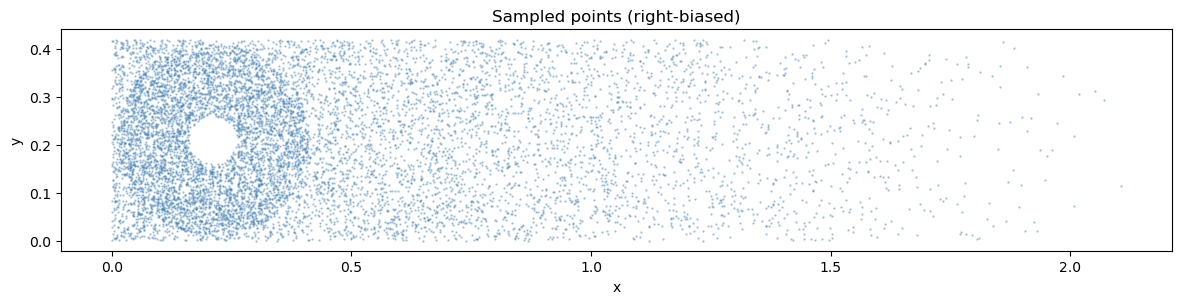

In [34]:
pts_np = sample_pts.cpu().numpy()

fig, ax = plt.subplots(figsize=(14, 3))
ax.scatter(pts_np[:, 0], pts_np[:, 1], s=0.5, alpha=0.4, color='steelblue')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Sampled points (right-biased)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


In [35]:
import h5py

# ── Evaluate model on sample points ───────────────────────────────────────────
pts = sample_pts.detach().requires_grad_(True)

with torch.enable_grad():
    out  = model_stream(pts)
    psi  = out[:, 0:1]
    p    = out[:, 1:2]
    psi_grad = grad(psi, pts, torch.ones_like(psi), create_graph=False)[0]
    u_vals   =  psi_grad[:, 1:2]   # u =  ∂ψ/∂y
    v_vals   = -psi_grad[:, 0:1]   # v = -∂ψ/∂x

x_np = sample_pts[:, 0:1].detach().cpu().numpy()
y_np = sample_pts[:, 1:2].detach().cpu().numpy()
u_np = u_vals.detach().cpu().numpy()
v_np = v_vals.detach().cpu().numpy()
p_np = p.detach().cpu().numpy()

# ── Save to HDF5 ──────────────────────────────────────────────────────────────
out_path = 'nav_stokes.h5'
with h5py.File(out_path, 'w') as f:
    f.create_dataset('x', data=x_np)
    f.create_dataset('y', data=y_np)
    f.create_dataset('u', data=u_np)
    f.create_dataset('v', data=v_np)
    f.create_dataset('p', data=p_np)

print(f"Saved {len(sample_pts)} points to '{out_path}'")
print(f"  x: {x_np.shape}  u: {u_np.shape}  v: {v_np.shape}  p: {p_np.shape}")


Saved 10000 points to 'nav_stokes.h5'
  x: (10000, 1)  u: (10000, 1)  v: (10000, 1)  p: (10000, 1)
